In [1]:
%run general_functions.ipynb

In [5]:
co2flux_base = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/co2flux_base70_lastDecade.nc')
co2flux_oae = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/co2flux_oae70_lastDecade.nc')
# co2flux_base = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/co2flux_base26_lastDecade.nc')

In [7]:
# ocean mask

mesk_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')
dx, dy = mesk_mask.e1t, mesk_mask.e2t
grid_cell_area = (dx * dy).isel(t=0)

mesk_mask['tmask'] = mesk_mask['tmask'].where(mesk_mask['tmask']!=0)
grid_cell_ocean = (mesk_mask['tmask'].isel(t=0,z=0)*grid_cell_area)
grid_cell_ocean = grid_cell_ocean.where(grid_cell_ocean)

ocean_slice = grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435)) # m-2

In [18]:
co2flux_change = co2flux_oae - co2flux_base
co2flux_change['co2flux'] = (co2flux_change['co2flux'] * 1000 / 44.009 * ocean_slice).sum(dim=['x','y','time_counter'])


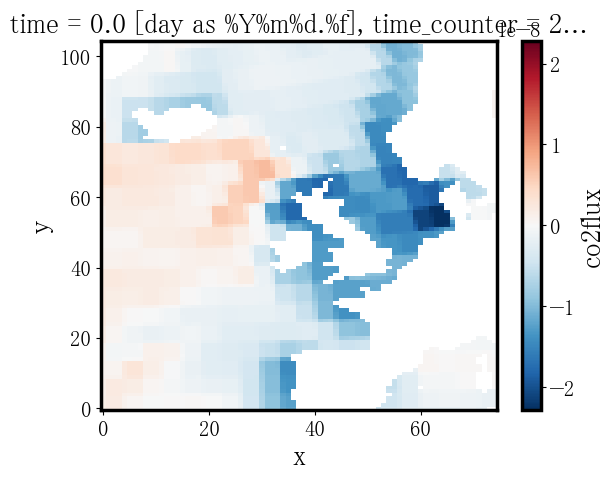

In [4]:
(co2flux_oae - co2flux_base).co2flux.isel(time_counter=0).plot()

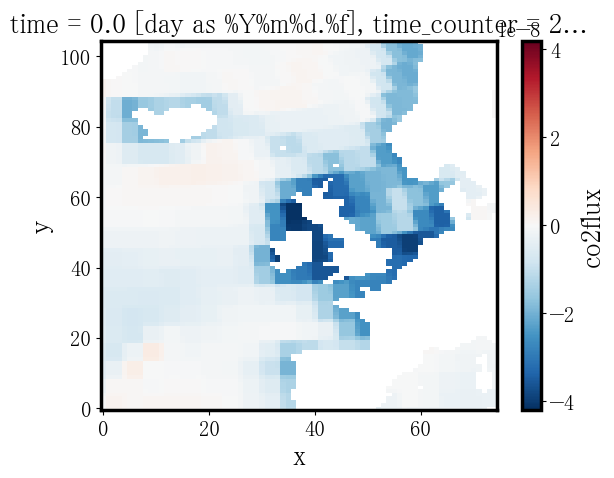

In [6]:
(co2flux_oae - co2flux_base).co2flux.isel(time_counter=0).plot()

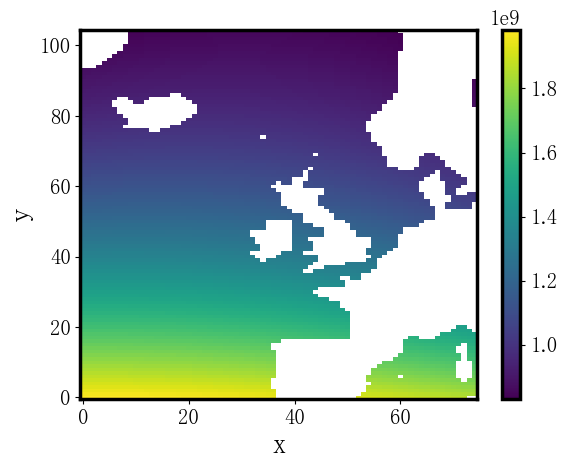

In [9]:
ocean_slice.plot()

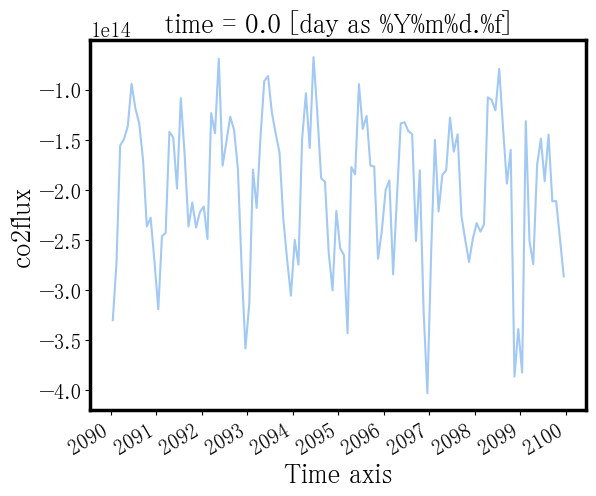

In [17]:
co2flux_change.co2flux.plot()